Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7960 - loss: 0.5374 - val_accuracy: 0.7975 - val_loss: 0.4926
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7960 - loss: 0.4875 - val_accuracy: 0.7975 - val_loss: 0.4657
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7960 - loss: 0.4676 - val_accuracy: 0.7975 - val_loss: 0.4516
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.4545 - val_accuracy: 0.7975 - val_loss: 0.4424
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.4455 - val_accuracy: 0.7975 - val_loss: 0.4372
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7960 - loss: 0.4392 - val_accuracy: 0.7975 - val_loss: 0.4328
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7979 - loss: 0.4350 - val_accuracy: 0.8095 - val_loss: 0.4302
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8077 - loss: 0.4317 - val_accu

C:\Users\akash\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


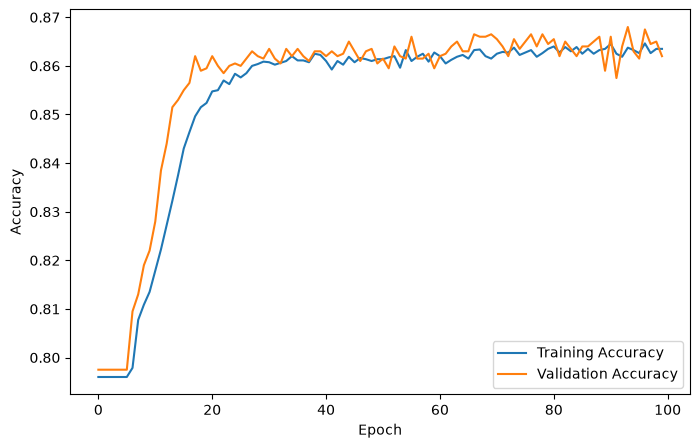

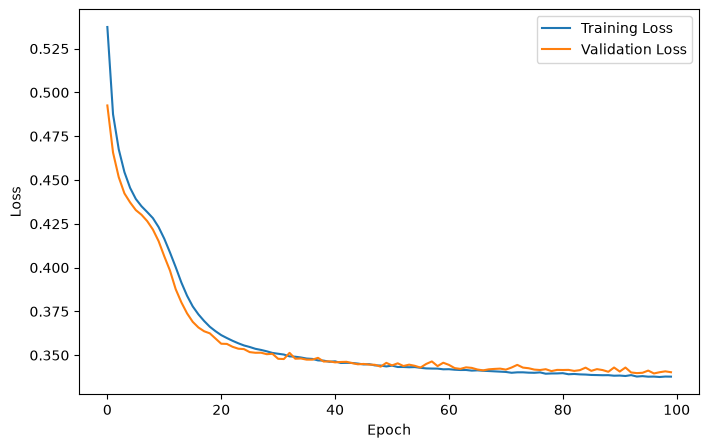

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\akash\OneDrive\Documents\Churn_Modelling.csv")
# Drop unnecessary columns
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)

# Encode categorical columns
le = LabelEncoder()
df["Geography"] = le.fit_transform(df["Geography"])
df["Gender"] = le.fit_transform(df["Gender"])

# Features and target
X = df.drop("Exited", axis=1)
y = df["Exited"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Feature scaling
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

# Build ANN
ann = tf.keras.models.Sequential()

# First hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation="relu"))

# Second hidden layer
ann.add(tf.keras.layers.Dense(units=6, activation="relu"))

# Output layer
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

# Compile ANN
ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train ANN
history = ann.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=100,
    validation_data=(X_test, y_test)
)

# Predict test set
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Accuracy
print("Accuracy =", accuracy_score(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Predict a single customer
pred = ann.predict(
    sc.transform([[600, 0, 1, 40, 3, 60000, 2, 1, 1, 50000]])
)

if pred > 0.5:
    print("Customer will leave the bank")
else:
    print("Customer will stay in the bank")

# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [4]:
import os
os.listdir()

['.ipynb_checkpoints',
 'cluster.ipynb',
 'desctree.ipynb',
 'employees.csv',
 'logisitcfinal.ipynb',
 'logistic regression.ipynb',
 'logisticregfinal.ipynb',
 'matplot.ipynb',
 'My Music',
 'My Pictures',
 'My Videos',
 'numpy.ipynb',
 'pandafinal.ipynb',
 'pillow.ipynb',
 'seaborn.ipynb',
 'Untitled.ipynb',
 'untitled.py',
 'Untitled1.ipynb',
 'Untitled2.ipynb',
 'Untitled3.ipynb',
 'Untitled4.ipynb']